In [1]:
!pip install yfinance
!pip install dtaidistance

In [2]:
# Importing necessary packages
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

In [3]:
# Importing tick data from COKE and PEP
ticker1 = yf.download('COKE', start='2020-01-01', end ='2024-12-31')
ticker2 = yf.download('PEP', start='2020-01-01', end ='2024-12-31')

# Extracting only Adjusted Close prices
coke_close = ticker1['Close']
pep_close = ticker2['Close']

# Drop any NaN values
coke_close = coke_close.dropna()
pep_close = pep_close.dropna()

# Align both series to same trading day
combined = pd.concat([coke_close, pep_close], axis=1).dropna()
combined.columns = ['COKE','PEP']

print(combined.shape)
print(combined.head)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(1257, 2)
<bound method NDFrame.head of                   COKE         PEP
Date                              
2020-01-02   26.822594  112.112411
2020-01-03   27.141727  111.955597
2020-01-06   26.785545  112.384789
2020-01-07   26.514854  110.618332
2020-01-08   26.334385  111.187904
...                ...         ...
2024-12-23  117.523224  144.188354
2024-12-24  119.361153  145.637009
2024-12-26  120.954742  145.284363
2024-12-27  121.912285  145.713242
2024-12-30  122.660118  144.598190

[1257 rows x 2 columns]>


In [4]:
# Apply log price transformation
coke_log = np.log(combined['COKE'])
pep_log = np.log(combined['PEP'])

print(coke_log.describe)
print(pep_log.describe)                

<bound method NDFrame.describe of Date
2020-01-02    3.289245
2020-01-03    3.301072
2020-01-06    3.287862
2020-01-07    3.277705
2020-01-08    3.270875
                ...   
2024-12-23    4.766636
2024-12-24    4.782154
2024-12-26    4.795416
2024-12-27    4.803302
2024-12-30    4.809417
Name: COKE, Length: 1257, dtype: float64>
<bound method NDFrame.describe of Date
2020-01-02    4.719502
2020-01-03    4.718102
2020-01-06    4.721929
2020-01-07    4.706086
2020-01-08    4.711222
                ...   
2024-12-23    4.971120
2024-12-24    4.981117
2024-12-26    4.978693
2024-12-27    4.981641
2024-12-30    4.973959
Name: PEP, Length: 1257, dtype: float64>


In [5]:
# Verify allignment
print(f'COKE length: {len(coke_log)}')
print(f'PEP length: {len(pep_log)}')
print(f'Same length: {len(coke_log) == len(pep_log)}')
print(f'Date range: {combined.index[0]} to {combined.index[-1]}')

COKE length: 1257
PEP length: 1257
Same length: True
Date range: 2020-01-02 00:00:00 to 2024-12-30 00:00:00


In [6]:
# Compute DTW distance using log prices
coke_array = coke_log.to_numpy()
pep_array = pep_log.to_numpy()

distance = dtw.distance(coke_array, pep_array)
print(f'DTW distance (log prices) between COKE and PEP: {distance:.4f}')
print(f'DTW distance (z-score) between COKE and PEP: 18.1058')
print(f'Difference: {abs(distance - 18.1058):.4f}')

DTW distance (log prices) between COKE and PEP: 28.9630
DTW distance (z-score) between COKE and PEP: 18.1058
Difference: 10.8572


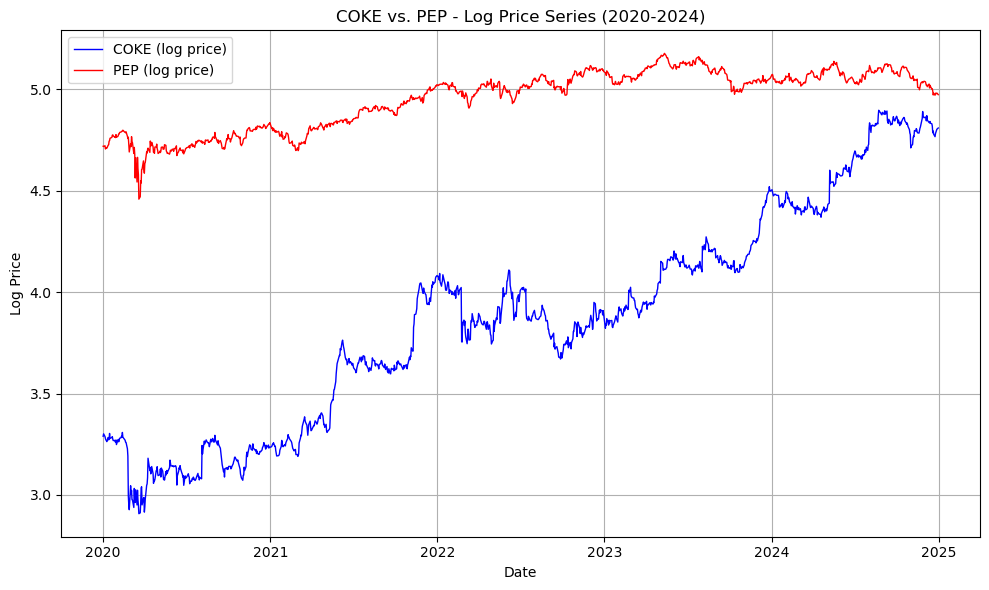

In [7]:
# Plot normalized price series
plt.figure(figsize=(10,6))
plt.plot(combined.index, coke_log, label='COKE (log price)', color='blue', linewidth=1)
plt.plot(combined.index, pep_log, label='PEP (log price)', color='red', linewidth=1)
plt.title('COKE vs. PEP - Log Price Series (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Log Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

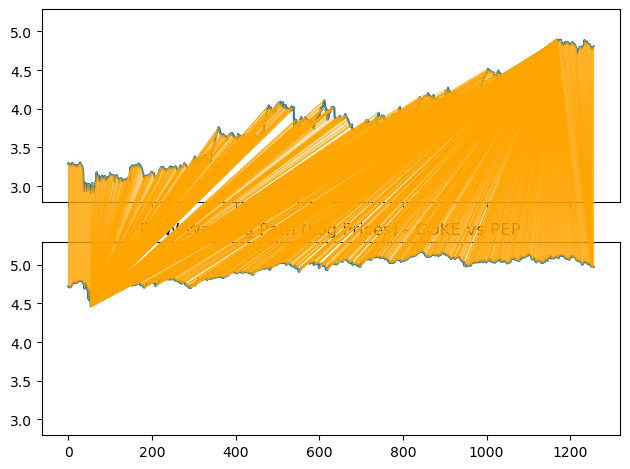

In [8]:
path = dtw.warping_path(coke_array, pep_array)
fig, ax = dtwvis.plot_warping(coke_array, pep_array, path)
plt.title("DTW Warping Path (Log Prices) - COKE vs PEP")
plt.tight_layout()
plt.show()